 # Classifiers KNN - SVM - MLP & CNN
 The goal of this extra is to do the same as the previous but with the MNIST dataset and a Convolutional Neural Network (CNN) classifier.

### Importing Libraries

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
# for the classifiers
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score, log_loss
from sklearn.neighbors import KNeighborsClassifier as KNN # K-Nearest Neighbors
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.neural_network import MLPClassifier as MLP # Multi-layer Perceptron

## MNIST dataset
Looking at the MNIST dataset by printing first 10 images with their labels, the number of samples for each label and its shape.

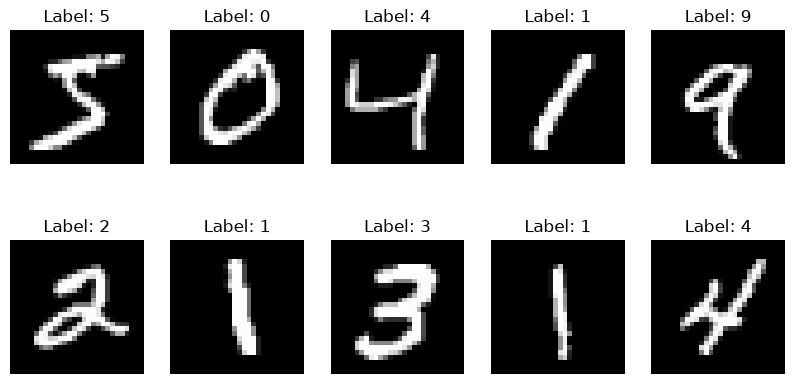

0:6903   1:7877   2:6990   3:7141   4:6824   5:6313   6:6876   7:7293   8:6825   9:6958  
X shape: (70000, 784) | y shape: (70000,)


In [14]:
mnist = fetch_openml("mnist_784", as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.axis('off')
    plt.imshow(X[i].reshape(28, 28), cmap='grey')
    plt.title(f"Label: {y[i]}")
plt.show()

print(*(f"{i}:{np.bincount(y)[i]}  " for i in range(10)))
print(f"X shape: {X.shape} | y shape: {y.shape}")

#### KNN - SVM - MLP
The next code cell will be used to train and test the KNN, SVM and MLP classifiers with the MNIST dataset. It will not use GridSearch, since the goal is just to show slow performance of these classifiers with a large dataset. The data will be scaled for MLP only as explained by the run on digits dataset.

For all three classifiers, the hyperparameters will be set by what I believe is the best for each classifier, based on the small previous runs, but nothing too fine-tuned, since the goal is to show the performance with a large dataset.

> Note: I know that the train/validation/test isn't worth it here, but since I use it in the MLP and CNN curves to understand what epochs to use, then I will use it here as well, because I want to compare the results of all classifiers in identical conditions.

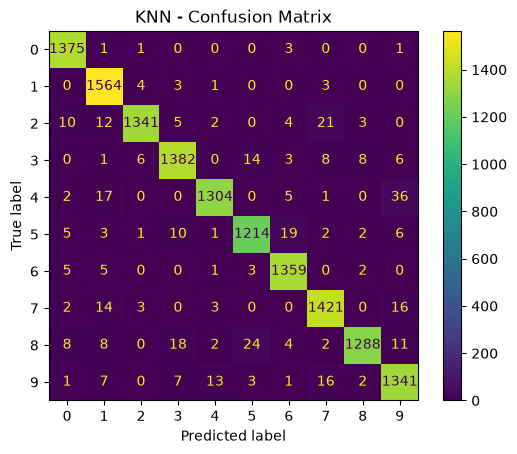

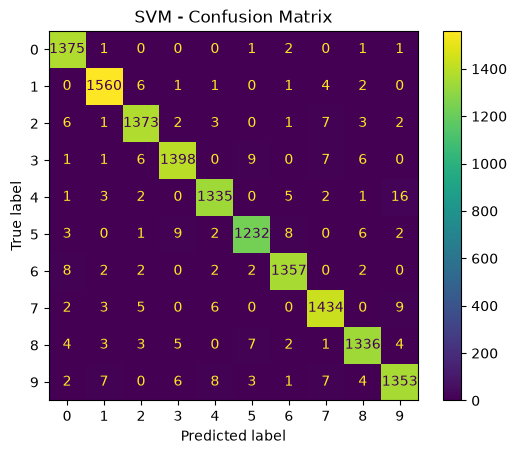

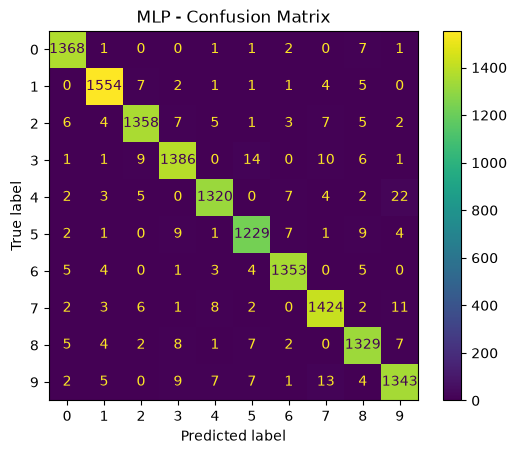

In [15]:
data_clf = list()
y_pred_clf = dict()

X_fit, X_val, y_fit, y_val = train_test_split(X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=42)

classifiers = {"KNN": KNN(n_neighbors=3, weights="distance"), 
               "SVM": SVC(C=10, gamma="scale", kernel="rbf"),
               "MLP": MLP(hidden_layer_sizes=(128, 64), alpha=0.1, learning_rate_init=0.0001, max_iter=1000, random_state=42)}

for name, clf in classifiers.items():
    if name == "MLP":
        pipe = make_pipeline(StandardScaler(), clf)
    else:
        pipe = clf

    t0 = time.perf_counter()
    pipe.fit(X_fit, y_fit)
    train_time = time.perf_counter() - t0

    y_val_pred = pipe.predict(X_val)
    
    t0 = time.perf_counter()
    y_pred = pipe.predict(X_te)
    pred_time = time.perf_counter() - t0

    y_pred_clf[name] = y_pred

    data_clf.append({"Classifier": name,
                     "Validation Accuracy": accuracy_score(y_val, y_val_pred),
                     "Accuracy": accuracy_score(y_te, y_pred),
                     "F1": f1_score(y_te, y_pred, average="macro"),
                     "Training Time (s)": train_time,
                     "Prediction Time per sample (ms)": pred_time / len(X_te) * 1000})

    ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

#### Just to check the epoch that MLP stops at

In [16]:
mlp = classifiers["MLP"]
print("Stopped at epoch:", mlp.n_iter_)

Stopped at epoch: 151


#### Results Tables for KNN, SVM and MLP

In [17]:
df = pd.DataFrame(data_clf).set_index("Classifier").round(4)
df

,Validation Accuracy,Accuracy,F1,Training Time (s),Prediction Time per sample (ms)
Classifier,,,,,
KNN,0.9719,0.9706,0.9705,0.0023,0.8073
SVM,0.9802,0.9824,0.9822,111.7890,5.3350
MLP,0.9759,0.9760,0.9759,269.2932,0.0065


### Training/Validation Loss & Accuracy Curve for MLP Classifier
This code will generate a plot with the training and cross-validation loss and accuracy curves for the MLP classifier, in order to visualize if the epoch number is correct.

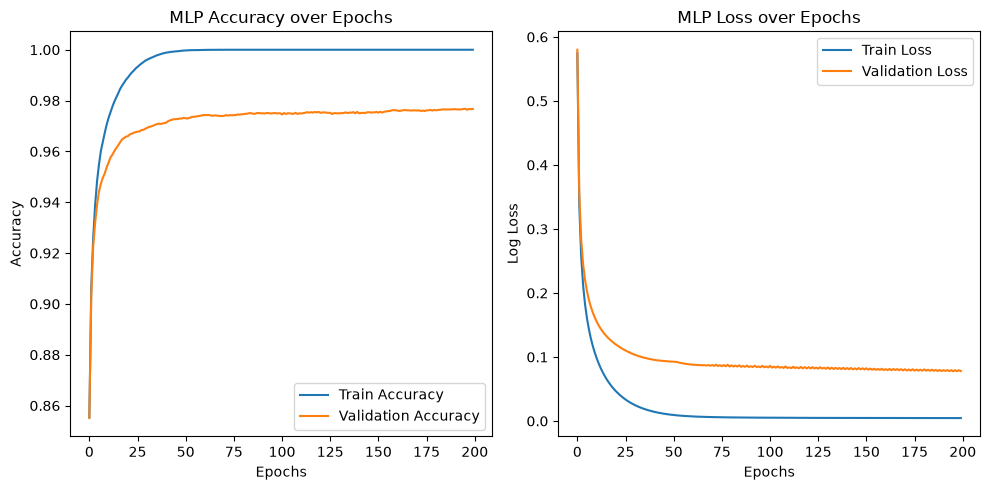

In [18]:
X_fit, X_val, y_fit, y_val = train_test_split(X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=42)

scaler = StandardScaler().fit(X_fit)
X_fit_s, X_val_s = scaler.transform(X_fit), scaler.transform(X_val)

mlp = MLP(hidden_layer_sizes=(128, 64), alpha=0.1, learning_rate_init=0.0001, random_state=42)
train_acc, val_acc = list(), list()
train_loss, val_loss = list(), list()

for epoch in range(200):
    mlp.partial_fit(X_fit_s, y_fit, classes=np.unique(y_tr))
    
    train_acc.append(mlp.score(X_fit_s, y_fit))
    val_acc.append(mlp.score(X_val_s, y_val))

    train_loss.append(log_loss(y_fit, mlp.predict_proba(X_fit_s)))
    val_loss.append(log_loss(y_val, mlp.predict_proba(X_val_s)))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.title("MLP Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.title("MLP Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Misclassified Images for KNN, SVM and MLP Classifiers

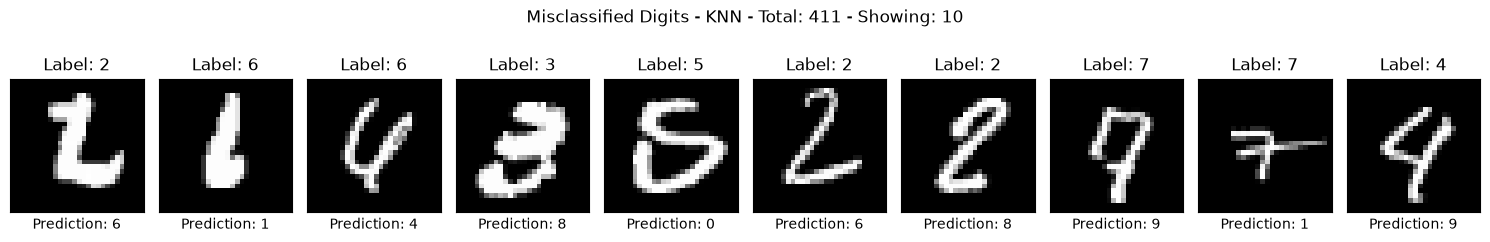

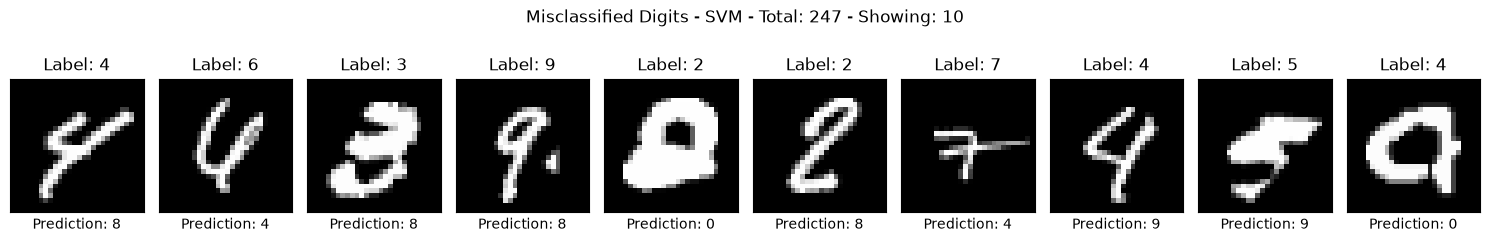

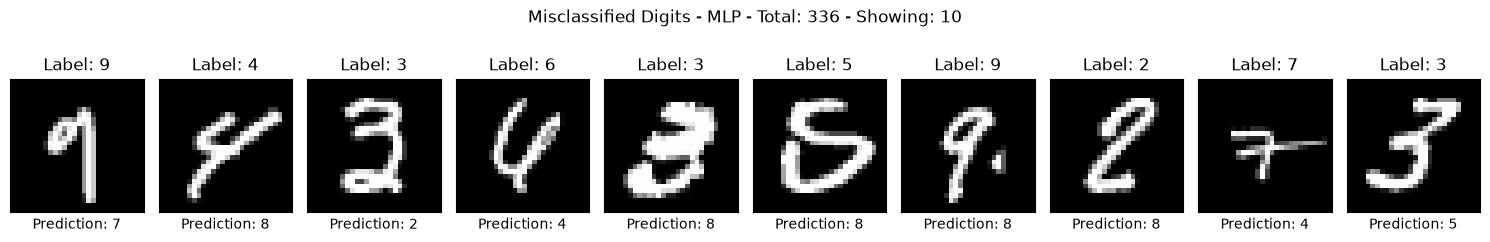

In [19]:
for name, y_pred in y_pred_clf.items():
    wrong = np.where(y_pred != y_te)[0]
    wrong_to_show = wrong[:10]
    n_cols = min(10, len(wrong_to_show))
    n_rows = int(np.ceil(len(wrong_to_show) / n_cols))

    plt.figure(figsize=(1.5 * n_cols, 2.5 * n_rows))
    plt.suptitle(f"Misclassified Digits - {name} - Total: {len(wrong)} - Showing: {len(wrong_to_show)}")

    for k, i in enumerate(wrong_to_show):
        plt.subplot(n_rows, n_cols, k + 1)
        plt.imshow(X_te[i].reshape(28, 28), cmap="gray")
        plt.title(f"Label: {y_te[i]}")
        plt.xlabel(f"Prediction: {y_pred[i]}")
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()


### CNN
> Not even going to bother testing without scaling, since CNN is a neural network and it will definitely benefit from scaling.

In [20]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.classifier = nn.Sequential(nn.Conv2d(1, 32, (3, 3), padding=1),
                                        nn.ReLU(),
                                        nn.MaxPool2d(2),
                                        nn.Conv2d(32, 64, (3,3), padding=1),
                                        nn.ReLU(),
                                        nn.MaxPool2d(2),
                                        nn.Flatten(),
                                        nn.Dropout(),
                                        nn.Linear(64 * 7 * 7, 128),
                                        nn.ReLU(),
                                        nn.Dropout(),
                                        nn.Linear(128, 10))

    def forward(self, x):
        return self.classifier(x)

In [21]:
def to_loader(X, y, batch, shuf):
    X_t = torch.tensor(X, dtype=torch.float32).reshape(-1, 1, 28, 28)
    y_t = torch.tensor(y, dtype=torch.long)

    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch, shuffle=shuf)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mean, std = X_fit.mean(), X_fit.std()
X_fit_s, X_val_s, X_te_s = (X_fit - mean) / std, (X_val - mean) / std, (X_te - mean) / std

fit_loader = to_loader(X_fit_s, y_fit, 128, True)
val_loader = to_loader(X_val_s, y_val, 1024, False)
test_loader = to_loader(X_te_s, y_te, 1024, False)

In [23]:
train_acc_cnn, val_acc_cnn = list(), list()
train_loss_cnn, val_loss_cnn = list(), list()

epochs = 20
torch.manual_seed(42)
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_time = 0.0
for epoch in range(epochs):
    t0 = time.perf_counter()

    model.train()
    total_loss, correct = 0.0, 0

    for xb, yb in fit_loader:

        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out, yb)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(yb)
        correct += (out.argmax(1) == yb).sum().item()

    train_time += time.perf_counter() - t0

    train_loss_cnn.append(total_loss / len(fit_loader.dataset))
    train_acc_cnn.append(correct / len(fit_loader.dataset))

    model.eval()
    total_loss, correct = 0.0, 0

    with torch.no_grad():
        for xb, yb in val_loader:

            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)

            total_loss += loss.item() * len(yb)
            correct += (out.argmax(1) == yb).sum().item()

    val_loss_cnn.append(total_loss / len(val_loader.dataset))
    val_acc_cnn.append(correct / len(val_loader.dataset))

    if ((epoch + 1) % 5 == 0): print(f"epoch: {epoch + 1}")


epoch: 5
epoch: 10
epoch: 15
epoch: 20


#### Training/Validation Loss & Accuracy Curve for the CNN

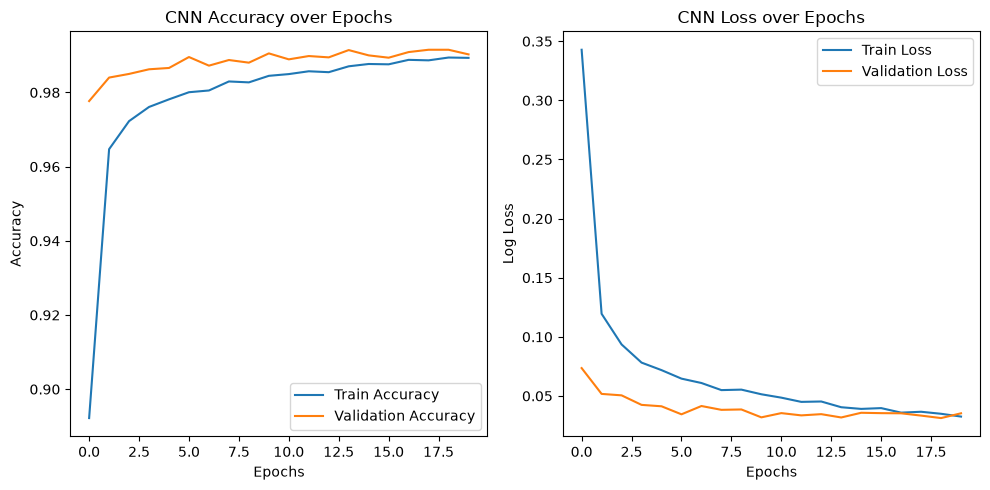

In [24]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_acc_cnn, label="Train Accuracy")
plt.plot(val_acc_cnn, label="Validation Accuracy")
plt.title("CNN Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_loss_cnn, label="Train Loss")
plt.plot(val_loss_cnn, label="Validation Loss")
plt.title("CNN Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.tight_layout()
plt.show()

> #### Conclusions about the graphs
> In the early epochs, validation accuracy is higher than training accuracy and the same with loss but in the opposite direction. That's because:
>- Training metrics are measured while Dropout is switched on, and averaged over the whole epoch, including the start when the model was still worse.
>- Validation is measured at the end of the epoch, with Dropout off.
>
> The Accuracy and Loss curves are as expected, converging around 20 epochs (checked the graph with 100 epochs and 20 is enough) and not overfitting.

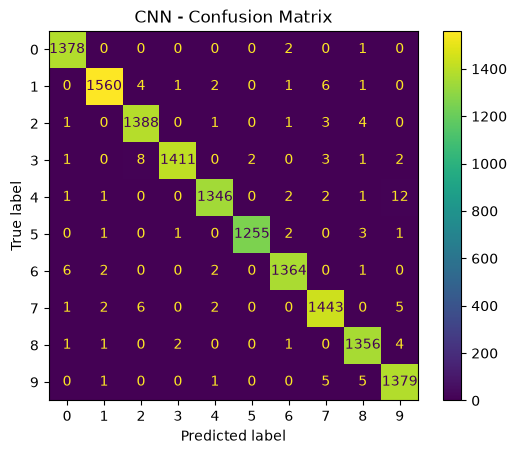

In [25]:
model.eval()
preds = list()

t0 = time.perf_counter()
with torch.no_grad():
    for xb, _ in test_loader:
        out = model(xb.to(device))
        preds.append(out.argmax(1).cpu().numpy())

pred_time = time.perf_counter() - t0

y_pred = np.concatenate(preds)
y_pred_clf["CNN"] = y_pred

data_clf = [d for d in data_clf if d["Classifier"] != "CNN"]
data_clf.append({"Classifier": "CNN",
                 "Validation Accuracy": val_acc_cnn[-1],
                 "Accuracy": accuracy_score(y_te, y_pred),
                 "F1": f1_score(y_te, y_pred, average="macro"),
                 "Training Time (s)": train_time,
                 "Prediction Time per sample (ms)": pred_time / len(X_te) * 1000})

ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
plt.title("CNN - Confusion Matrix")
plt.show()

### Results Table

In [26]:
pd.DataFrame(data_clf).set_index("Classifier").round(4)

,Validation Accuracy,Accuracy,F1,Training Time (s),Prediction Time per sample (ms)
Classifier,,,,,
KNN,0.9719,0.9706,0.9705,0.0023,0.8073
SVM,0.9802,0.9824,0.9822,111.7890,5.3350
MLP,0.9759,0.9760,0.9759,269.2932,0.0065
CNN,0.9903,0.9914,0.9915,30.9956,0.0123


### Conclusions for the classifiers
**Accuracy:** CNN (99.14%) > SVM (98.24%) > MLP (97.60%) > KNN (97.06%). CNN is the only model that uses the 2D structure of the image which makes it detect local patterns anywhere in the image, while KNN, SVM and MLP see 784 independent numbers.

**Validation vs test:** the accuracies differ by at most 0.2 percentage points for every model, so the validation set was a reliable estimate and no model overfitted to it.

**Compared with the digits dataset:** the SVM is still the best of the classical models, but the ranking of the other two flipped. KNN was second on digits and is now the worst, the MLP becomes better the more data it has thanks to pattern recognition.

**Training time:** KNN only stores the data making it instant, while SVM (112s) and MLP (269s) require substantial computation. The CNN trained in 31 s with GPU.

**Prediction time:** KNN compares each image with all the other training images (0.81 ms), and the SVM evaluates the kernel against thousands of support vectors (5.3 ms, ~430× slower than the CNN). The MLP (0.0065 ms, CPU) and the CNN (0.012 ms, GPU) are just a few matrix multiplications, so they are practically instant.

**Overall:** for image data the CNN is the clear choice, being the most accurate and fast at prediction. Among the classical models, the SVM gives the best accuracy but is the slowest to use, and the MLP is the best balance once trained.

### Misclassified Images for the CNN

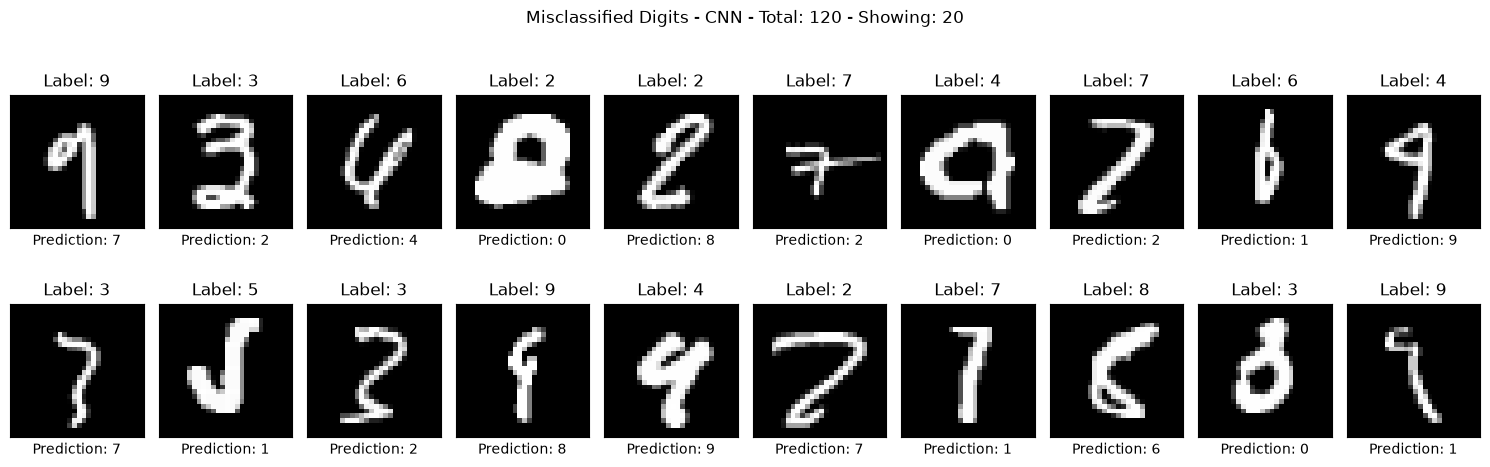

In [27]:
wrong = np.where(y_pred_clf["CNN"] != y_te)[0]
wrong_to_show = wrong[:20]
n_cols = min(10, len(wrong_to_show))
n_rows = int(np.ceil(len(wrong_to_show) / n_cols))

plt.figure(figsize=(1.5 * n_cols, 2.5 * n_rows))
plt.suptitle(f"Misclassified Digits - CNN - Total: {len(wrong)} - Showing: {len(wrong_to_show)}")

for k, i in enumerate(wrong_to_show):
    plt.subplot(n_rows, n_cols, k + 1)
    plt.imshow(X_te[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_te[i]}")
    plt.xlabel(f"Prediction: {y_pred_clf['CNN'][i]}")
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

#### Conclusions about mislabeled images
Most of the CNN's errors are between digits with similar shapes, like 4 - 9 or 7 - 2, and many of them are badly written and hard to classify even for a human.